# Desarrollo y validación del decoder geométrico

Este notebook documenta el desarrollo incremental del decoder utilizado para
transformar un orden de piezas y sus orientaciones en un layout geométricamente
válido.

Las pruebas se realizan inicialmente sobre subconjuntos pequeños de piezas y
posteriormente sobre las 99 instancias del problema SHIRTS.

También se incluyen pruebas de rendimiento que permitieron identificar
cuellos de botella y optimizar la generación y validación de posiciones
candidatas.

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
from pathlib import Path
import time

import matplotlib.pyplot as plt

from nesting.dataset import load_problem
from nesting.decoder import decode_solution
from nesting.geometry import (
    get_ifp_geometry,
    get_oriented_piece,
    validate_layout,
)
from nesting.visualization import plot_layout

In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

XML_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "shirts.xml"
)

problem = load_problem(XML_PATH)

In [4]:
print("Problema:", problem.name)
print("Tipos de piezas:", len(problem.piece_types))
print("Cantidad total de piezas:", len(problem.piece_instances))
print("NFP cargados:", len(problem.nfp_lookup))
print("IFP cargados:", len(problem.ifp_lookup))
print("Bounds del tablero:", problem.board_geometry.bounds)

Problema: Shirts
Tipos de piezas: 8
Cantidad total de piezas: 99
NFP cargados: 256
IFP cargados: 16
Bounds del tablero: (0.0, 0.0, 1000.0, 40.0)


## Verificación del IFP

El XML almacena los IFP utilizando como referencia la esquina mínima
de la caja envolvente de cada pieza.

Como el decoder trabaja con el punto de referencia original `(0, 0)`
de la geometría, `get_ifp_geometry()` aplica una corrección para llevar
ambos sistemas de coordenadas al mismo marco de referencia.

In [5]:
piece = get_oriented_piece(
    problem,
    polygon_id="polygon1",
    angle=0,
)

raw_ifp_id = problem.ifp_lookup[
    ("polygon0", "polygon1", 0)
]

raw_ifp = problem.geometries[
    raw_ifp_id
]

corrected_ifp = get_ifp_geometry(
    problem,
    piece_polygon_id="polygon1",
    piece_angle=0,
)

print("ID del IFP:        ", raw_ifp_id)
print("Bounds pieza:      ", piece.bounds)
print("Bounds IFP raw:    ", raw_ifp.bounds)
print("Bounds IFP correg.:", corrected_ifp.bounds)

ID del IFP:         ifpPolygon0
Bounds pieza:       (-2.0, 0.0, 7.0, 7.0)
Bounds IFP raw:     (0.0, 0.0, 991.0, 33.0)
Bounds IFP correg.: (2.0, 0.0, 993.0, 33.0)


In [6]:
import nesting.geometry as geometry

print(
    hasattr(
        geometry,
        "extract_coordinates_from_geometry",
    )
)

True


In [7]:
print(
    geometry.extract_coordinates_from_geometry
)

<function extract_coordinates_from_geometry at 0x000002624AAEDF80>


## Prueba del decoder con 3 piezas

Se realiza una primera prueba controlada utilizando tres instancias del
mismo tipo de pieza, todas con orientación de 0°.

El objetivo es verificar que el decoder genere un layout factible y que,
mientras exista espacio disponible en el ancho de la tela, tienda a
compactar las piezas sin aumentar innecesariamente la longitud utilizada.

In [8]:
order_3 = [0, 1, 2]

orientations_3 = [
    0
    for _ in problem.piece_instances
]

result_3 = decode_solution(
    problem=problem,
    order=order_3,
    orientations=orientations_3,
)

print("Piezas colocadas:", len(result_3.placements))
print("Longitud utilizada:", result_3.used_length)

Piezas colocadas: 3
Longitud utilizada: 9.0


In [9]:
for placement in result_3.placements:
    print(
        f"Instancia {placement.instance_id} | "
        f"{placement.polygon_id} | "
        f"{placement.angle}° | "
        f"ref=({placement.reference_x:.2f}, "
        f"{placement.reference_y:.2f}) | "
        f"bounds={tuple(round(v, 2) for v in placement.geometry.bounds)}"
    )

Instancia 0 | polygon1 | 0° | ref=(2.00, 0.00) | bounds=(0.0, 0.0, 9.0, 7.0)
Instancia 1 | polygon1 | 0° | ref=(2.00, 7.00) | bounds=(0.0, 7.0, 9.0, 14.0)
Instancia 2 | polygon1 | 0° | ref=(2.00, 14.00) | bounds=(0.0, 14.0, 9.0, 21.0)


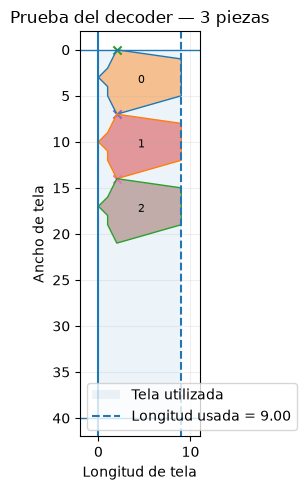

In [10]:
fig, ax = plot_layout(
    result_3,
    board_width=40,
    title="Prueba del decoder — 3 piezas",
    show_reference_points=True,
    show_instance_ids=True,
    figsize=(10, 5),
)

plt.show()

## Prueba del decoder con 10 piezas

Se amplía la prueba a 10 piezas para verificar el comportamiento del
decoder cuando aparecen distintas instancias y tipos de piezas.

El objetivo es observar cómo el decoder aprovecha primero el ancho
disponible de la tela y comienza a incrementar la longitud utilizada
cuando ya no puede seguir compactando verticalmente.

In [11]:
order_10 = list(range(10))

orientations_10 = [
    0
    for _ in problem.piece_instances
]

result_10 = decode_solution(
    problem=problem,
    order=order_10,
    orientations=orientations_10,
)

print("Piezas colocadas:", len(result_10.placements))
print("Longitud utilizada:", result_10.used_length)

Piezas colocadas: 10
Longitud utilizada: 22.4


In [12]:
for placement in result_10.placements:
    print(
        f"Instancia {placement.instance_id:02d} | "
        f"{placement.polygon_id:8s} | "
        f"{placement.angle:3d}° | "
        f"ref=({placement.reference_x:.2f}, "
        f"{placement.reference_y:.2f}) | "
        f"bounds={tuple(round(v, 2) for v in placement.geometry.bounds)}"
    )

Instancia 00 | polygon1 |   0° | ref=(2.00, 0.00) | bounds=(0.0, 0.0, 9.0, 7.0)
Instancia 01 | polygon1 |   0° | ref=(2.00, 7.00) | bounds=(0.0, 7.0, 9.0, 14.0)
Instancia 02 | polygon1 |   0° | ref=(2.00, 14.00) | bounds=(0.0, 14.0, 9.0, 21.0)
Instancia 03 | polygon1 |   0° | ref=(2.00, 21.00) | bounds=(0.0, 21.0, 9.0, 28.0)
Instancia 04 | polygon1 |   0° | ref=(2.00, 28.00) | bounds=(0.0, 28.0, 9.0, 35.0)
Instancia 05 | polygon1 |   0° | ref=(9.00, 33.00) | bounds=(7.0, 33.0, 16.0, 40.0)
Instancia 06 | polygon1 |   0° | ref=(10.00, 3.00) | bounds=(8.0, 3.0, 17.0, 10.0)
Instancia 07 | polygon1 |   0° | ref=(10.00, 10.00) | bounds=(8.0, 10.0, 17.0, 17.0)
Instancia 08 | polygon2 |   0° | ref=(10.40, 17.80) | bounds=(9.4, 17.8, 22.4, 23.8)
Instancia 09 | polygon2 |   0° | ref=(10.40, 24.80) | bounds=(9.4, 24.8, 22.4, 30.8)


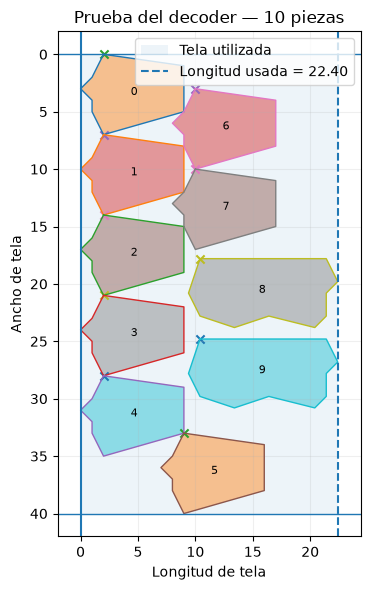

In [13]:
fig, ax = plot_layout(
    result_10,
    board_width=40,
    title="Prueba del decoder — 10 piezas",
    show_reference_points=True,
    show_instance_ids=True,
    figsize=(14, 6),
)

plt.show()

## Validación geométrica del layout

Además de la inspección visual, se verifica automáticamente que todas
las piezas permanezcan dentro de los límites de la tela y que no exista
solapamiento con área positiva entre ningún par de piezas.

In [14]:
geometries_10 = [
    placement.geometry
    for placement in result_10.placements
]

is_valid_10, errors_10 = validate_layout(
    board_geometry=problem.board_geometry,
    geometries=geometries_10,
)

print("Layout válido:", is_valid_10)
print("Errores encontrados:", len(errors_10))

Layout válido: True
Errores encontrados: 0


## Baseline con las 99 piezas

Se evalúa el decoder sobre la instancia completa utilizando:

- el orden original de las piezas;
- orientación fija de 0° para todas las instancias.

Esta configuración se utiliza como baseline inicial para comparar luego
contra las soluciones obtenidas mediante el algoritmo genético.

In [15]:
order_99 = list(
    range(len(problem.piece_instances))
)

orientations_99 = [
    0
    for _ in problem.piece_instances
]

start_time = time.perf_counter()

result_99 = decode_solution(
    problem=problem,
    order=order_99,
    orientations=orientations_99,
)

elapsed_time = (
    time.perf_counter()
    - start_time
)

print("Piezas colocadas:", len(result_99.placements))
print("Longitud utilizada:", round(result_99.used_length, 3))
print("Tiempo de ejecución:", round(elapsed_time, 3), "s")

Piezas colocadas: 99
Longitud utilizada: 79.5
Tiempo de ejecución: 7.857 s


In [16]:
geometries_99 = [
    placement.geometry
    for placement in result_99.placements
]

is_valid_99, errors_99 = validate_layout(
    board_geometry=problem.board_geometry,
    geometries=geometries_99,
)

print("Layout válido:", is_valid_99)
print("Errores encontrados:", len(errors_99))

Layout válido: True
Errores encontrados: 0


In [17]:
total_piece_area = sum(
    problem.geometries[
        piece.polygon_id
    ].area
    for piece in problem.piece_instances
)

board_width = (
    problem.board_geometry.bounds[3]
    - problem.board_geometry.bounds[1]
)

used_fabric_area = (
    result_99.used_length
    * board_width
)

utilization = (
    total_piece_area
    / used_fabric_area
)

theoretical_lower_bound = (
    total_piece_area
    / board_width
)

print(f"Área total de piezas:   {total_piece_area:.2f}")
print(f"Ancho de tela:          {board_width:.2f}")
print(f"Longitud utilizada:     {result_99.used_length:.2f}")
print(f"Aprovechamiento:        {utilization * 100:.2f}%")
print(f"Cota inferior por área: {theoretical_lower_bound:.2f}")

Área total de piezas:   2160.00
Ancho de tela:          40.00
Longitud utilizada:     79.50
Aprovechamiento:        67.92%
Cota inferior por área: 54.00


In [18]:
import cProfile
import pstats
import io

In [19]:
profiler = cProfile.Profile()

profiler.enable()

profile_result = decode_solution(
    problem=problem,
    order=order_99,
    orientations=orientations_99,
)

profiler.disable()

In [20]:
stream = io.StringIO()

stats = pstats.Stats(
    profiler,
    stream=stream,
)

stats.sort_stats(
    pstats.SortKey.CUMULATIVE
)

stats.print_stats(25)

print(stream.getvalue())

         10620168 function calls (10590545 primitive calls) in 16.617 seconds

   Ordered by: cumulative time
   List reduced from 140 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000   16.617    8.308 c:\Users\pc\OneDrive\Escritorio\EIA\AE\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3739(run_code)
        2    0.000    0.000   16.616    8.308 {built-in method builtins.exec}
        1    0.000    0.000   16.616   16.616 C:\Users\pc\AppData\Local\Temp\ipykernel_19208\2381612435.py:1(<module>)
        1    0.011    0.011   16.616   16.616 C:\Users\pc\OneDrive\Escritorio\EIA\AE\src\nesting\decoder.py:589(decode_solution)
       99    0.217    0.002   16.605    0.168 C:\Users\pc\OneDrive\Escritorio\EIA\AE\src\nesting\decoder.py:357(place_next_piece)
   696259    2.470    0.000    9.528    0.000 c:\Users\pc\OneDrive\Escritorio\EIA\AE\.venv\Lib\site-packages\shapely\decorators.py:73(wrapped)
      

In [21]:
import statistics


execution_times = []

for run in range(3):

    start_time = time.perf_counter()

    result_benchmark = decode_solution(
        problem=problem,
        order=order_99,
        orientations=orientations_99,
    )

    elapsed = (
        time.perf_counter()
        - start_time
    )

    execution_times.append(elapsed)

    print(
        f"Ejecución {run + 1}: "
        f"{elapsed:.3f} s"
    )


print()
print(
    "Tiempo promedio:",
    f"{statistics.mean(execution_times):.3f} s",
)

print(
    "Mediana:",
    f"{statistics.median(execution_times):.3f} s",
)

print(
    "Mejor tiempo:",
    f"{min(execution_times):.3f} s",
)

Ejecución 1: 7.921 s
Ejecución 2: 8.644 s
Ejecución 3: 7.964 s

Tiempo promedio: 8.176 s
Mediana: 7.964 s
Mejor tiempo: 7.921 s


## Baseline heurístico: piezas de mayor área primero

Como segunda referencia se utiliza una heurística simple: ordenar las
instancias de mayor a menor área antes de aplicar el mismo decoder
constructivo.

Este baseline permite evaluar si una mejora respecto del orden original
puede obtenerse únicamente mediante una regla determinística sencilla,
antes de utilizar el algoritmo genético.

Las orientaciones se mantienen inicialmente en 0° para aislar el efecto
del orden de las piezas.

In [22]:
instances_by_area = sorted(
    problem.piece_instances,
    key=lambda instance: problem.geometries[
        instance.polygon_id
    ].area,
    reverse=True,
)

order_area = [
    instance.instance_id
    for instance in instances_by_area
]

orientations_area = [
    0
    for _ in problem.piece_instances
]

In [23]:
for instance in instances_by_area[:15]:

    area = problem.geometries[
        instance.polygon_id
    ].area

    print(
        f"Instancia {instance.instance_id:02d} | "
        f"{instance.polygon_id:8s} | "
        f"área = {area:.2f}"
    )

Instancia 16 | polygon3 | área = 86.00
Instancia 17 | polygon3 | área = 86.00
Instancia 18 | polygon3 | área = 86.00
Instancia 19 | polygon3 | área = 86.00
Instancia 20 | polygon3 | área = 86.00
Instancia 21 | polygon3 | área = 86.00
Instancia 22 | polygon3 | área = 86.00
Instancia 23 | polygon3 | área = 86.00
Instancia 08 | polygon2 | área = 64.50
Instancia 09 | polygon2 | área = 64.50
Instancia 10 | polygon2 | área = 64.50
Instancia 11 | polygon2 | área = 64.50
Instancia 12 | polygon2 | área = 64.50
Instancia 13 | polygon2 | área = 64.50
Instancia 14 | polygon2 | área = 64.50


In [24]:
start_time = time.perf_counter()

result_area = decode_solution(
    problem=problem,
    order=order_area,
    orientations=orientations_area,
)

elapsed_area = (
    time.perf_counter()
    - start_time
)

print(
    "Piezas colocadas:",
    len(result_area.placements),
)

print(
    "Longitud utilizada:",
    result_area.used_length,
)

print(
    "Tiempo de ejecución:",
    round(elapsed_area, 3),
    "s",
)

Piezas colocadas: 99
Longitud utilizada: 76.94444445
Tiempo de ejecución: 7.981 s


In [25]:
geometries_area = [
    placement.geometry
    for placement in result_area.placements
]

valid_area, errors_area = validate_layout(
    board_geometry=problem.board_geometry,
    geometries=geometries_area,
)

print("Layout válido:", valid_area)
print("Errores:", len(errors_area))

Layout válido: True
Errores: 0


In [26]:
utilization_original = (
    total_piece_area
    / (
        board_width
        * result_99.used_length
    )
)

utilization_area = (
    total_piece_area
    / (
        board_width
        * result_area.used_length
    )
)

improvement_area = (
    (
        result_99.used_length
        - result_area.used_length
    )
    / result_99.used_length
    * 100
)

print("BASELINE ORIGINAL")
print(
    f"Longitud:       {result_99.used_length:.2f}"
)
print(
    f"Aprovechamiento: "
    f"{utilization_original * 100:.2f}%"
)

print()

print("MAYOR ÁREA PRIMERO")
print(
    f"Longitud:       {result_area.used_length:.2f}"
)
print(
    f"Aprovechamiento: "
    f"{utilization_area * 100:.2f}%"
)

print()

print(
    f"Variación de longitud: "
    f"{improvement_area:.2f}%"
)

BASELINE ORIGINAL
Longitud:       79.50
Aprovechamiento: 67.92%

MAYOR ÁREA PRIMERO
Longitud:       76.94
Aprovechamiento: 70.18%

Variación de longitud: 3.21%


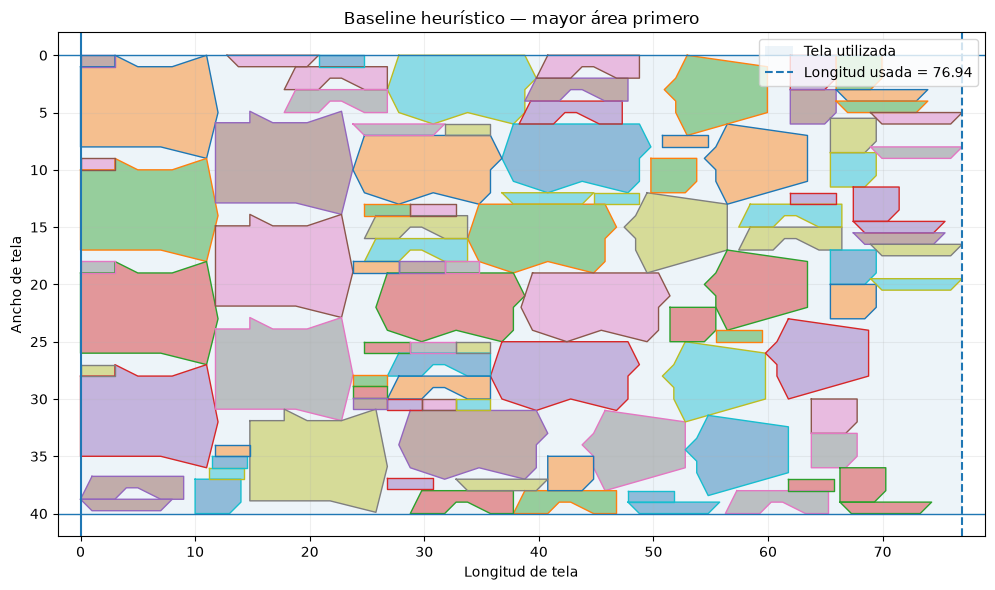

In [27]:
fig, ax = plot_layout(
    result_area,
    board_width=40,
    title="Baseline heurístico — mayor área primero",
    show_reference_points=False,
    show_instance_ids=False,
    figsize=(14, 6),
)

plt.show()

In [28]:
# Baseline original recalculado
start_time = time.perf_counter()

result_original_final = decode_solution(
    problem=problem,
    order=order_99,
    orientations=orientations_99,
)

time_original_final = (
    time.perf_counter()
    - start_time
)


# Baseline por área recalculado
start_time = time.perf_counter()

result_area_final = decode_solution(
    problem=problem,
    order=order_area,
    orientations=orientations_area,
)

time_area_final = (
    time.perf_counter()
    - start_time
)

In [29]:
original_geometries_final = [
    placement.geometry
    for placement in result_original_final.placements
]

area_geometries_final = [
    placement.geometry
    for placement in result_area_final.placements
]


valid_original_final, errors_original_final = validate_layout(
    board_geometry=problem.board_geometry,
    geometries=original_geometries_final,
)

valid_area_final, errors_area_final = validate_layout(
    board_geometry=problem.board_geometry,
    geometries=area_geometries_final,
)

In [30]:
utilization_original_final = (
    total_piece_area
    / (
        board_width
        * result_original_final.used_length
    )
)

utilization_area_final = (
    total_piece_area
    / (
        board_width
        * result_area_final.used_length
    )
)

improvement_final = (
    (
        result_original_final.used_length
        - result_area_final.used_length
    )
    / result_original_final.used_length
    * 100
)


print("BASELINE ORIGINAL")
print(
    f"Longitud:        "
    f"{result_original_final.used_length:.2f}"
)
print(
    f"Aprovechamiento: "
    f"{utilization_original_final * 100:.2f}%"
)
print(
    f"Tiempo:          "
    f"{time_original_final:.3f} s"
)
print(
    f"Layout válido:   "
    f"{valid_original_final}"
)

print()

print("MAYOR ÁREA PRIMERO")
print(
    f"Longitud:        "
    f"{result_area_final.used_length:.2f}"
)
print(
    f"Aprovechamiento: "
    f"{utilization_area_final * 100:.2f}%"
)
print(
    f"Tiempo:          "
    f"{time_area_final:.3f} s"
)
print(
    f"Layout válido:   "
    f"{valid_area_final}"
)

print()

print(
    f"Mejora de longitud: "
    f"{improvement_final:.2f}%"
)

BASELINE ORIGINAL
Longitud:        79.50
Aprovechamiento: 67.92%
Tiempo:          8.270 s
Layout válido:   True

MAYOR ÁREA PRIMERO
Longitud:        76.94
Aprovechamiento: 70.18%
Tiempo:          7.486 s
Layout válido:   True

Mejora de longitud: 3.21%
